<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4018 non-null   object 
 1   Open    4002 non-null   float64
 2   High    4011 non-null   float64
 3   Low     4011 non-null   float64
 4   Close   4008 non-null   float64
 5   Volume  4012 non-null   float64
 6   Name    4018 non-null   object 
dtypes: float64(5), object(2)
memory usage: 219.9+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 3974 entries, 0 to 4017
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    3974 non-null   datetime64[ns]
 1   Open    3974 non-null   float64       
 2   High    3974 non-null   float64       
 3   Low     3974 non-null   float64       
 4   Close   3974 non-null   float64       
 5   Volume  3974 non-null   float64       
 6   Name    3974 non-null   object        
dtypes: da

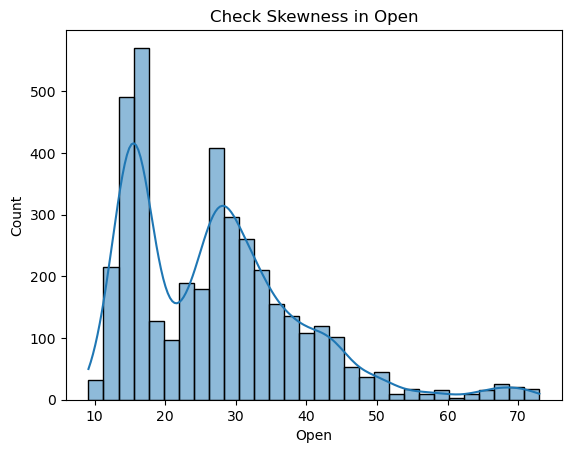

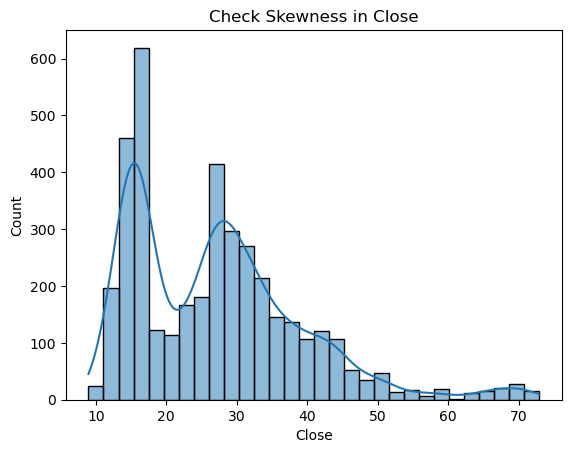

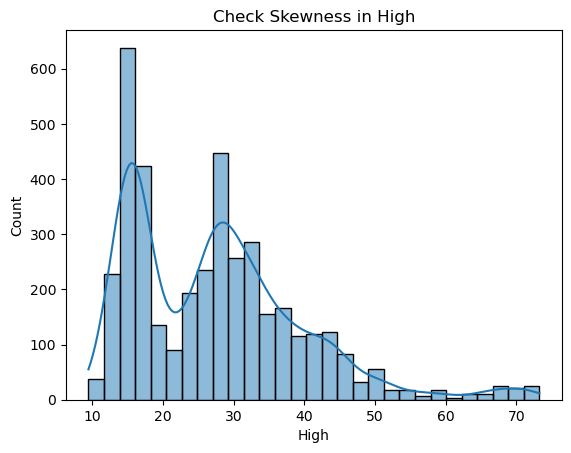

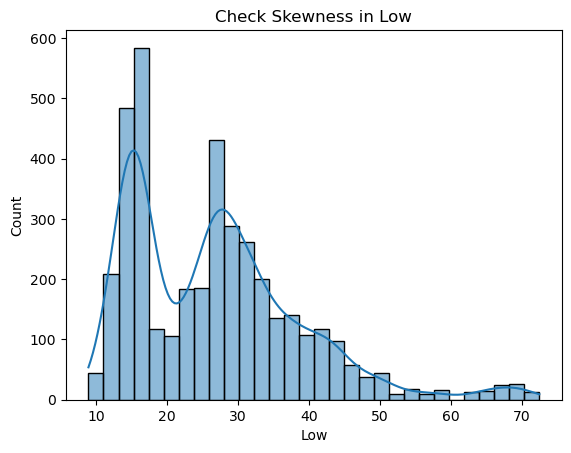

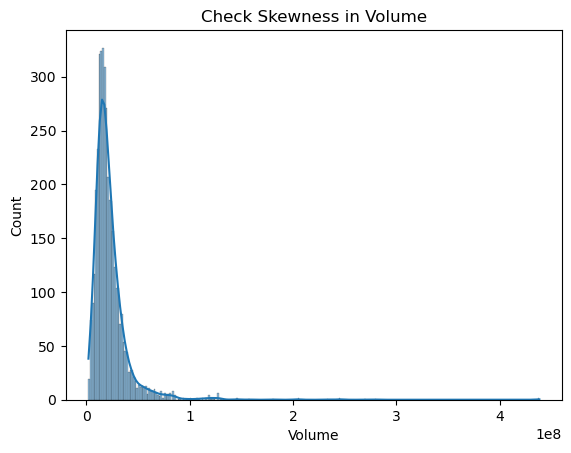

Skew: 1.0808586152690902
Skew: 1.0835957808784382
Skew: 1.0784351129092418
Skew: 1.0866723408520214
Skew: 7.842050629819112


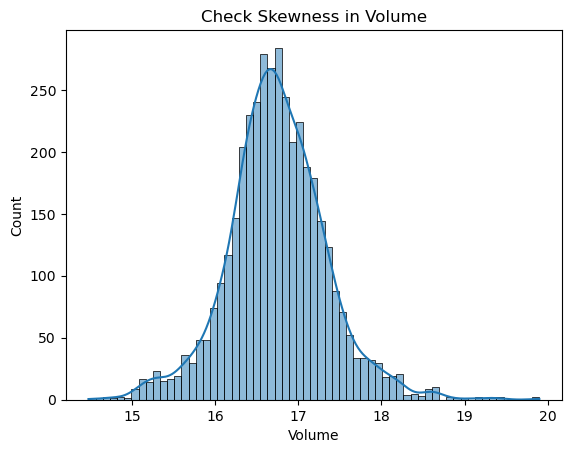

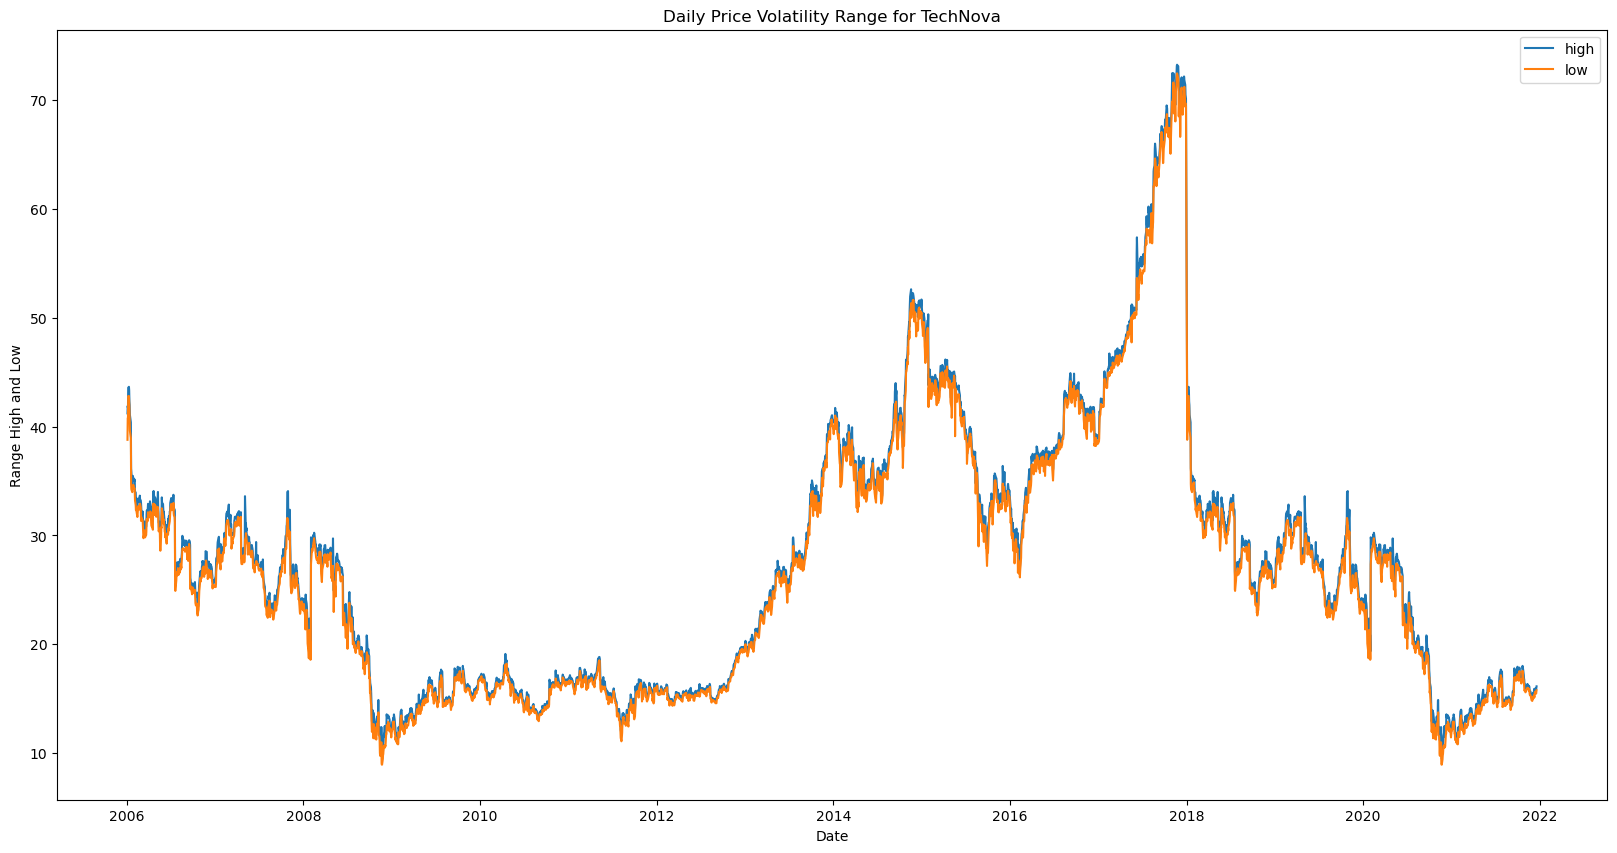

Correlation Between Close and Volume: -0.3655


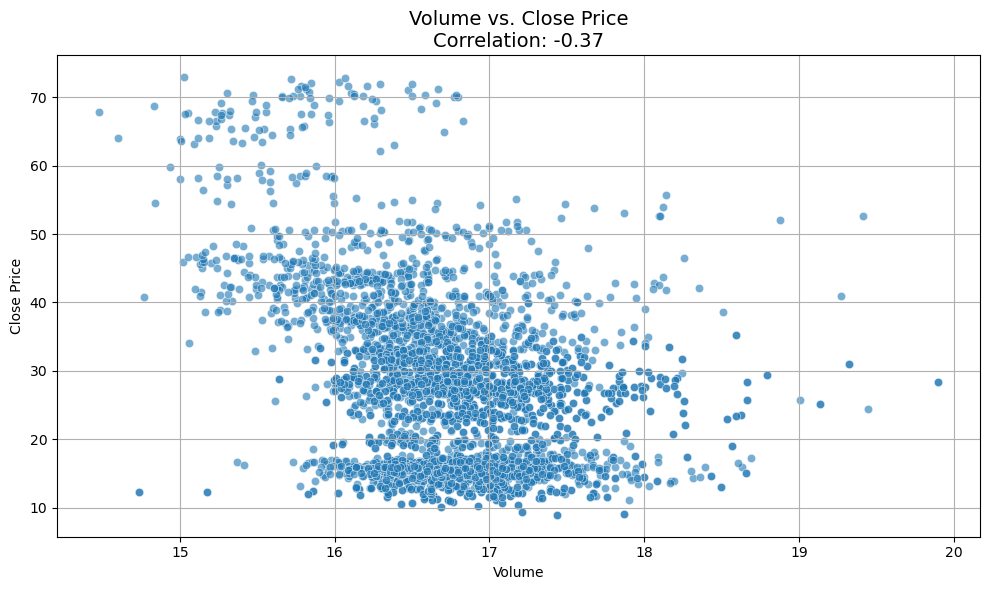

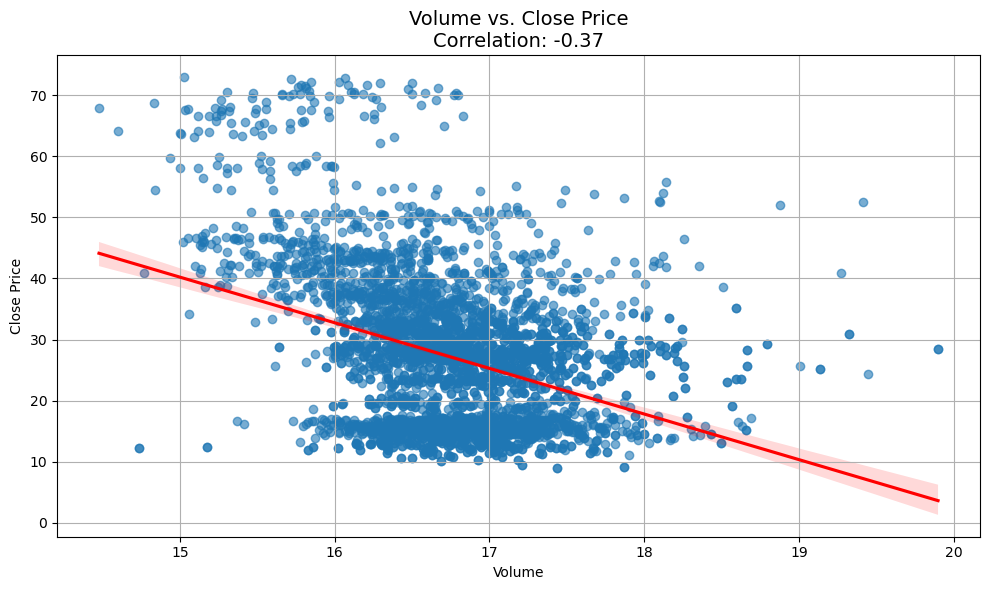

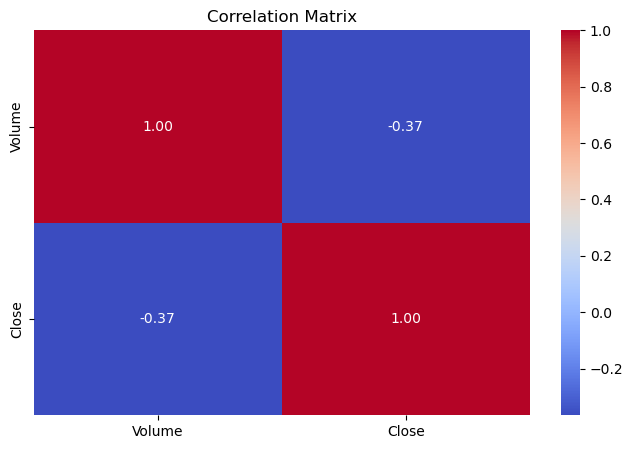


Logistic:
Accuracy: 0.5056603773584906
[[125 280]
 [113 277]]
              precision    recall  f1-score   support

           0       0.53      0.31      0.39       405
           1       0.50      0.71      0.59       390

    accuracy                           0.51       795
   macro avg       0.51      0.51      0.49       795
weighted avg       0.51      0.51      0.49       795


DecisionTree:
Accuracy: 0.7182389937106918
[[287 118]
 [106 284]]
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       405
           1       0.71      0.73      0.72       390

    accuracy                           0.72       795
   macro avg       0.72      0.72      0.72       795
weighted avg       0.72      0.72      0.72       795

Best Parameters: {'max_depth': 7, 'min_samples_split': 2}
Best cross_validated Score: 0.5316144208389046


In [1]:
# Import necessary libraries 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Load dataset 
df = pd.read_csv("Data_Set_PDA_4051_1.csv") 
20 

# Display info of the dataset 
df.info() 

# Display first 5 rows of the dataset 
df.head() 

# Check for missing values in column 
df.isnull().sum()

# Get descriptive statistics for numerical columns 
df.describe()

# Drop rows with any missing values 
df.dropna(inplace=True)

# Confirm missing values removed 
df.isnull().sum()

# Convert 'Date' column to datetime format 
df['Date'] = pd.to_datetime(df['Date']) 

# Check the data types after conversion 
df.info() 
21 

# Show updated descriptive statistics 
df.describe() 

# Plot distribution of 'Open' prices with KDE to check skewness 
sns.histplot(df['Open'], kde=True) 
plt.title('Check Skewness in Open') 
plt.show() 

# Plot distribution of 'Close' prices with KDE to check skewness 
sns.histplot(df['Close'], kde=True) 
plt.title('Check Skewness in Close') 
plt.show() 

# Plot distribution of 'High' prices with KDE to check skewness 
sns.histplot(df['High'], kde=True) 
plt.title('Check Skewness in High') 
plt.show() 

# Plot distribution of 'Low' prices with KDE to check skewness 
sns.histplot(df['Low'], kde=True) 
plt.title('Check Skewness in Low') 
plt.show() 

# Plot distribution of 'Volume' with KDE to check skewness 
sns.histplot(df['Volume'], kde=True) 
22 
plt.title('Check Skewness in Volume') 
plt.show() 

# Print skewness values for all key numeric columns 
print('Skew:', df['Open'].skew()) 
print('Skew:', df['Close'].skew()) 
print('Skew:', df['High'].skew()) 
print('Skew:', df['Low'].skew()) 
print('Skew:', df['Volume'].skew()) 

# Apply log transformation to 'Volume' to reduce skewness 
df['Volume'] = np.log(df['Volume'] + 1) 

# Plot 'Volume' again after transformation 
sns.histplot(df['Volume'], kde=True) 
plt.title('Check Skewness in Volume') 
plt.show() 

# Plot time series of 'High' and 'Low' prices to show price volatility 
plt.figure(figsize=(20, 10)) 
sns.lineplot(x=df['Date'], y=df['High'], label='high') 
sns.lineplot(x=df['Date'], y=df['Low'], label='low') 
plt.title('Daily Price Volatility Range for TechNova') 
plt.ylabel('Range High and Low') 
plt.xlabel('Date') 
23 
plt.show() 

# Create a new DataFrame with 'Open' and 'Close' columns 
open_close_df = df[['Open', 'Close']] 
open_close_df 

# Ensure the data is sorted by date 
df = df.sort_values("Date") 

# Calculate correlation between 'Close' price and 'Volume' 
correlation = df["Close"].corr(df["Volume"]) 
print(f"Correlation Between Close and Volume: {correlation:.4f}") 

# Scatter plot of Volume vs. Close to visualize correlation 
plt.figure(figsize=(10, 6)) 
sns.scatterplot(x='Volume', y='Close', data=df, alpha=0.6) 
plt.title(f'Volume vs. Close Price\nCorrelation: {correlation:.2f}', fontsize=14) 
plt.xlabel('Volume') 
plt.ylabel('Close Price') 
plt.grid(True) 
plt.tight_layout() 
plt.show() 

# Regression plot to show linear relationship between Volume and Close 
df['Date'] = pd.to_datetime(df['Date']) 
24 
df = df.sort_values('Date') 
correlation = df['Close'].corr(df['Volume']) 
plt.figure(figsize=(10, 6)) 
sns.regplot( 
x='Volume', y='Close', data=df, 
scatter_kws={'alpha': 0.6}, 
line_kws={'color': 'red'} 
) 
plt.title(f'Volume vs. Close Price\nCorrelation: {correlation:.2f}', fontsize=14) 
plt.xlabel('Volume') 
plt.ylabel('Close Price') 
plt.grid(True) 
plt.tight_layout() 
plt.show() 

# Heatmap to visualize correlation matrix of 'Volume' and 'Close' 
corr_matrix = df[['Volume', 'Close']].corr() 
plt.figure(figsize=(8, 5)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f') 
plt.title('Correlation Matrix') 
plt.show() 

# Create target variable: 1 if next day's Close > today's Close, else 0 
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int) 
25 

# Drop any rows with nan values 
df.dropna(inplace=True) 

# Import tools for splitting data and scaling features 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 

# Select features and target variable 
features = ['High', 'Low', 'Volume'] 
X = df[features] 
y = df['Target'] 

# Split data into training and testing sets (80% train, 20% test) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

# Scale features using StandardScaler 
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

# Import and train Logistic Regression model 
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
26 
lr = LogisticRegression() 
lr.fit(X_train_scaled, y_train) 

# Train Decision Tree Classifier 
dt = DecisionTreeClassifier(random_state=42) 
dt.fit(X_train, y_train) 

# Import evaluation metrics 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 

# Evaluate Logistic Regression model 
print("\nLogistic:") 
y_pred_lr = lr.predict(X_test_scaled) 
print("Accuracy:", accuracy_score(y_test, y_pred_lr)) 
print(confusion_matrix(y_test, y_pred_lr)) 
print(classification_report(y_test, y_pred_lr)) 

# Evaluate Decision Tree model 
print("\nDecisionTree:") 
y_pred_dt = dt.predict(X_test) 
print("Accuracy:", accuracy_score(y_test, y_pred_dt)) 
print(confusion_matrix(y_test, y_pred_dt)) 
print(classification_report(y_test, y_pred_dt)) 

# Import GridSearchCV for hyperparameter tuning 
27 
from sklearn.model_selection import GridSearchCV 

# Define hyperparameter grid for Decision Tree 
param_grid = { 
'max_depth': [3, 5, 7], 
'min_samples_split': [2, 5, 10] 
} 

# Perform grid search with 5-fold cross-validation 
grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5) 
grid.fit(X_train, y_train) 

# Output best hyperparameters and corresponding score 
print("Best Parameters:", grid.best_params_) 
print("Best cross_validated Score:", grid.best_score_) 